# Project Name: Shopper Spectrum
# Github Link: https://github.com/meetpatel94/Shopper-Spectrum_Lab-Mantix

# Now Step:1 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load Datasets
df = pd.read_csv("online_retail.csv")

In [5]:
#Dataset View ( First 5 )
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
#Rows & Columns Count
df.shape

(541909, 8)

In [7]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Step:2 Data Preprocessing (Data Cleaning)

In [8]:
# Missing CustomerID Remove & check
df = df.dropna(subset=['CustomerID'])
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
# Cancelled Invoices Remove
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [10]:
# Negative / Zero Quantity Remove & Negative Zero Price
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
# Now after Data Cleaning Dataset Size Check
df.shape

(397884, 8)

# Now Step:3 Exploratory Data Analysis

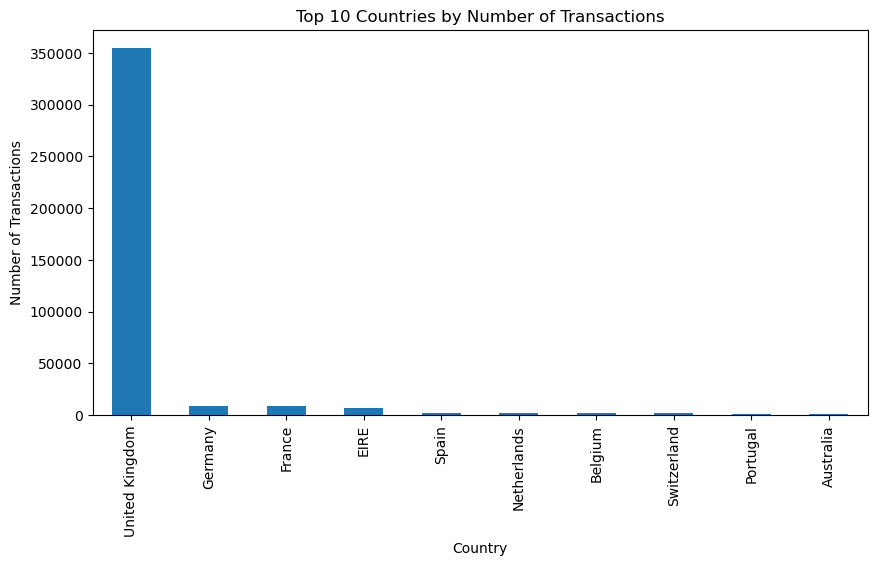

In [12]:
# chart-1 Transactions by Country
country_counts = df['Country'].value_counts().head(10)

country_counts

# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
country_counts.plot(kind='bar')
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.show()


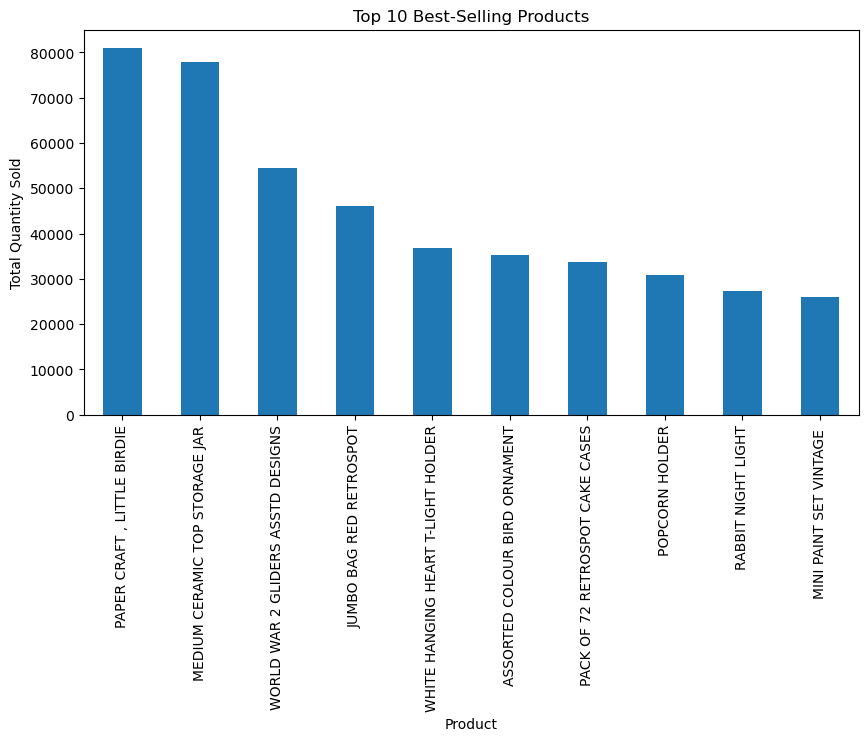

In [13]:
# chart - 2 Top-Selling Products
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

# plot
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.show()

C:\Users\rspat\AppData\Local\Temp\ipykernel_2620\4165529828.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['Quantity'] * x['UnitPrice']).sum())


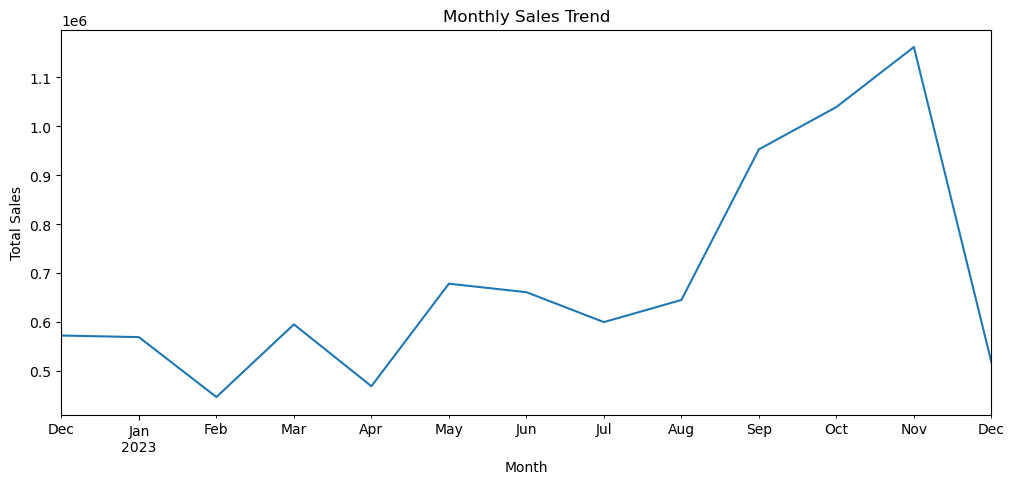

In [14]:
# chart - 3 Sales Trend Over Time
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')
    .apply(lambda x: (x['Quantity'] * x['UnitPrice']).sum())
)

monthly_sales

#plot
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


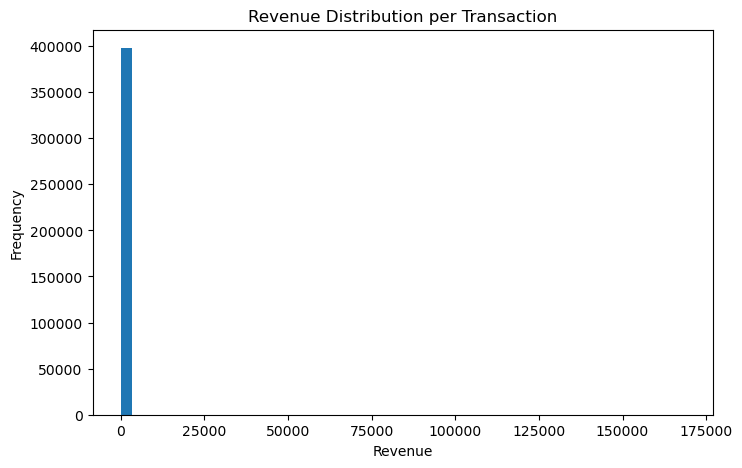

In [15]:
#chart - 4 Revenue Distribution

df['Revenue'] = df['Quantity'] * df['UnitPrice']

plt.figure(figsize=(8,5))
plt.hist(df['Revenue'], bins=50)
plt.title("Revenue Distribution per Transaction")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()


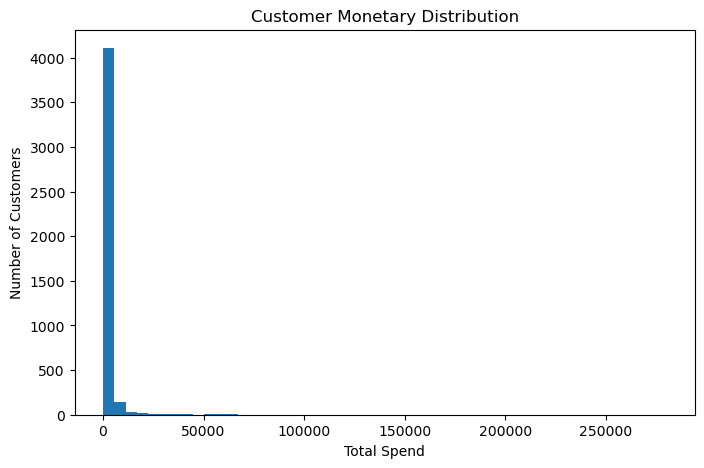

In [16]:
# chart - 5 RFM Distributions (Preview Analysis)
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()

plt.figure(figsize=(8,5))
plt.hist(customer_revenue, bins=50)
plt.title("Customer Monetary Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.show()

# Now step:4 RFM Feature Engineering

In [17]:
# Create Total Revenue Column & Set Reference Date
df['Revenue'] = df['Quantity'] * df['UnitPrice']
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


In [18]:
# Create RFM Table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'count',
    'Revenue': 'sum'
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()
rfm.describe()


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,91.720609,2054.266460
std,1721.808492,100.014169,228.785094,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,17.000000,307.415000
50%,15299.500000,51.000000,41.000000,674.485000
75%,16778.750000,142.000000,100.000000,1661.740000
max,18287.000000,374.000000,7847.000000,280206.020000


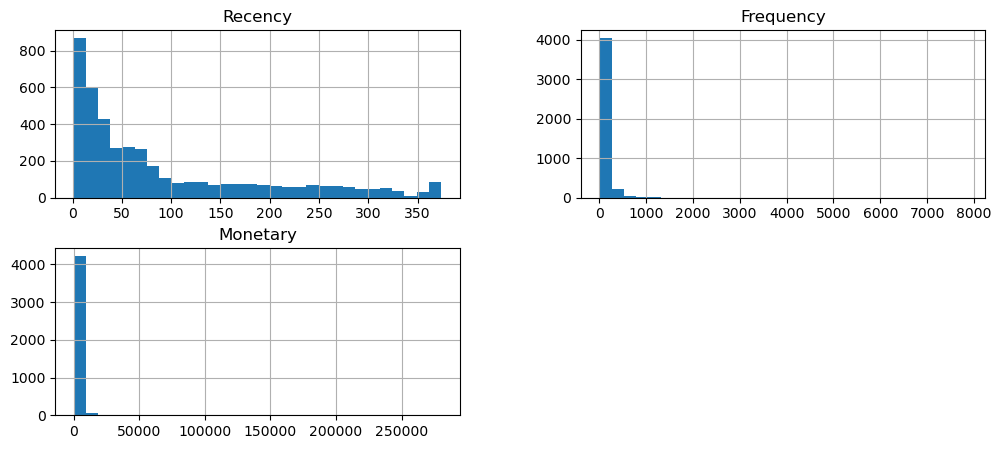

In [19]:
# Now 
import matplotlib.pyplot as plt
rfm[['Recency','Frequency','Monetary']].hist(bins=30, figsize=(12,5))
plt.show()

# Now, Step:5 RFM Scaling & Customer Clustering (KMeans)

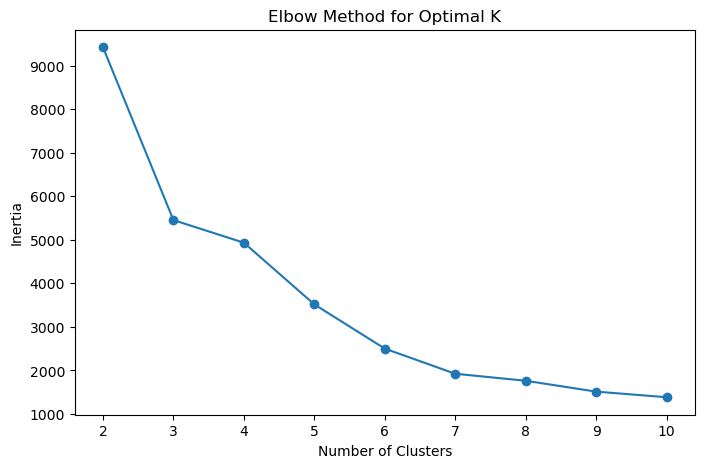

In [20]:
# RFM Features Select & RFM Scaling
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


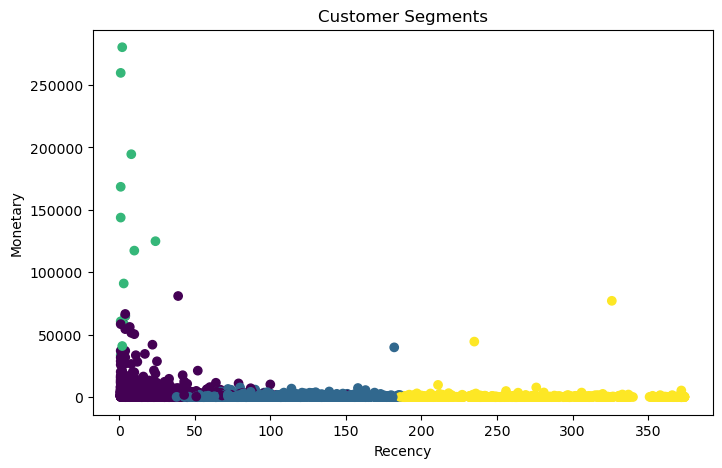

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
cluster_summary

def label_cluster(row):
    if row['Frequency'] > rfm['Frequency'].mean() and row['Monetary'] > rfm['Monetary'].mean():
        return 'High-Value'
    elif row['Frequency'] > rfm['Frequency'].mean():
        return 'Regular'
    elif row['Recency'] > rfm['Recency'].mean():
        return 'At-Risk'
    else:
        return 'Occasional'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)

plt.figure(figsize=(8,5))
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments")
plt.show()



In [22]:
import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


# Now Step:6 Product Recommendation System

In [23]:
# Create Customer–Product Matrix
product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)
product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Calculate Product Similarity 
from sklearn.metrics.pairwise import cosine_similarity
product_similarity = cosine_similarity(product_matrix.T)

# Create Similarity DataFrame
similarity_df = pd.DataFrame(
    product_similarity,
    index=product_matrix.columns,
    columns=product_matrix.columns
)

In [25]:
# create Recommendation Function
def recommend_products(product_name, top_n=5):
    if product_name not in similarity_df.index:
        return "Product not found"

    similar_scores = similarity_df[product_name].sort_values(ascending=False)
    recommended = similar_scores.iloc[1:top_n+1].index.tolist()
    return recommended
    
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

['GIN + TONIC DIET METAL SIGN',
 'RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER']

In [26]:
# Save For Streamlit
import pickle

with open("product_similarity.pkl", "wb") as f:
    pickle.dump(similarity_df, f)


# Run File/Project On Streamlit

**In terminal or CMD :-** streamlit run app.py

In [27]:
# Check for product names in Streamlit (20)
df['Description'].dropna().unique()[:20]

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER',
       'KNITTED UNION FLAG HOT WATER BOTTLE',
       'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES',
       'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER UNION JACK',
       'HAND WARMER RED POLKA DOT', 'ASSORTED COLOUR BIRD ORNAMENT',
       "POPPY'S PLAYHOUSE BEDROOM ", "POPPY'S PLAYHOUSE KITCHEN",
       'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY ',
       'BOX OF 6 ASSORTED COLOUR TEASPOONS',
       'BOX OF VINTAGE JIGSAW BLOCKS ', 'BOX OF VINTAGE ALPHABET BLOCKS',
       'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD',
       'RECIPE BOX WITH METAL HEART'], dtype=object)

# Future Work

- **Real-Time Customer Data Integration:** Currently, the system works on historical transaction data.
 In the future, it can be extended to process real-time customer transactions, allowing businesses to dynamically update customer segments and recommendations.

- **Advanced Recommendation Techniques:** The current recommendation system uses item-based collaborative filtering.
Future work can include - Hybrid recommendation systems (collaborative + content-based)
Deep learning–based recommendation models - This would improve recommendation accuracy, especially for new users and products.

- **Dynamic Customer Segment Tracking:** At present, customer segments are static based on historical behavior.
In future, customer movement between segments (e.g., Regular → High-Value or High-Value → At-Risk) can be tracked over time to support proactive retention strategies.

- **Integration with CRM and ERP Systems:** Future versions of the system can be integrated with CRM or ERP platforms, enabling seamless use of customer insights for inventory management, targeted promotions, and customer relationship management.

- **Enhanced Streamlit Dashboard and Visual Analytics:** The Streamlit application can be enhanced with - Interactive charts and filters, Drill-down views by country or product category, Role-based dashboards for managers and analysts

- **Model Optimization and Evaluation:** Clustering performance can be further improved by - Testing multiple clustering algorithms (DBSCAN, Hierarchical), Applying automated hyperparameter tuning, Regular re-training as new data becomes available